## Advanced Data Challenge - Track3 : Hierarchical decision making
__Content creators:__ Sungshin Kim


### 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Gläscher et al. designed a probabilistic sequential Markov decision task involving choices in two successive internal states, followed by a rewarded outcome state.  

 The task has the structure of a decision tree, in which each abstract decision state is represented by a fractal image as shown below.  

 In each trial, the participants begin at the same starting state and choose between a left or right button press.  

 Probabilistically, they reach one of two subsequent states, each of which presents another choice between a left or right action.  

 Finally, they reach one of three probabilistic outcome states providing a reward of 0¢, 10¢, or 25¢.

<br><br><br>
<img alt="HierarchicalDecisionMaking" width="625" height="700" src="https://www.cell.com/cms/attachment/fab9cacc-68a9-4571-83cc-0aa4d8c86884/gr1.jpg">
<br><br>


### 2. Class for the hierarchical decision making environment 

In [2]:
class HierarchicalBanditTask:
    """
    A class representing a hierarchical 2-armed bandit task.
    Written by Sungshin Kim
    """
    def __init__(self):
        """
        Initialize the hierarchical bandit task.
        """
        self.state = 0
    
    
    def step(self, action):
        """
        Take a step in the hierarchical bandit task.

        Args:
            action (tuple): action taken by agent, 0 or 1

        Returns:
            tuple: A tuple (state, reward) representing the
                states and reward after taking an action
                
        """

        if self.state == 0:
            if action == 0:
                self.state = np.random.choice([1, 2], p=[0.7, 0.3])
            else:
                self.state = np.random.choice([3, 4], p=[0.7, 0.3])
            reward = 0
        elif self.state==1: 
            if action==0:
                reward = np.random.choice([10, 0], p=[0.7, 0.3])
            else:
                reward = np.random.choice([0, 10], p=[0.7, 0.3])
            self.state = None
        elif self.state==2:
            if action==0:
                reward = np.random.choice([0, 10], p=[0.7, 0.3])
            else:
                reward = np.random.choice([0, 25], p=[0.7, 0.3])
            self.state = None
        elif self.state==3:
            if action==0:
                reward = np.random.choice([25, 0], p=[0.7, 0.3])
            else:
                reward = np.random.choice([10, 0], p=[0.7, 0.3])            
            self.state = None
        else: # self.state==4
            if action==0:
                reward = np.random.choice([0, 10], p=[0.7, 0.3])
            else:
                reward = np.random.choice([0, 25], p=[0.7, 0.3])   
            self.state = None
        return (self.state, reward) ## next state, reward
    
    def reset(self):
        self.state = 0
        return self.state

### 3. Model-free reinforcement learning agent

In [3]:
# I chose epsilon-greedy policy instead of softmax because it performed better.
# For softmax, just replace def choose with the below code, and change parameters appropriately

# # Compute the probabilities for each action using the softmax function
# probs = np.exp(self.q_values[state] / self.tau)
# probs /= np.sum(probs)

# # Sample an action from the probability distribution
# action = np.random.choice(self.n_actions, p=probs)

In [12]:
class QLearningAgent:
    """
    A class representing an agent performing Q-learning with an epsilon-greedy policy on the 
    HierarchicalBanditTask environment.
    """
    def __init__(self, n_states, n_actions, lr=0.01, gamma=0.99, epsilon=1, epsilon_decay=0.9995, epsilon_min=0.01):
        """
        Initialize the Q-learning agent.

        Args:
            n_states (int): The number of states in the environment.
            n_actions (int): The number of actions available to the agent.
            lr (float): The learning rate for Q-learning updates (default: 0.1).
            gamma (float) : The discount factor for future rewards (default: 0.99)
            epsilon (float): The initial exploration rate for the epsilon-greedy policy (default: 1.0)
            epsilon_decay (float) : The decay rate for episilon (default: 0.99)
            epsilon_min (float) : The minimum value of epsilon
        """
        self.n_states = n_states
        self.n_actions = n_actions
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_values = np.zeros((n_states, n_actions))

    
    
    def choose(self, state):
        """
        Select an action for the given state (e.g., soft-max, epsilon-greedy etc).
        Args:
            state (int): The current state of the environment.
        Returns:
            int: The selected action.
        """
        self.epsilon = max(self.epsilon_min, self.epsilon*self.epsilon_decay)
        if np.random.rand() < self.epsilon:
            action = np.random.choice(2)
        else:
            action = np.argmax(self.q_values[state])
        return action
    
    
    def update(self, state, action, reward, next_state):
        """
        Update the Q-value for the current state and action.

        Args:
            state (int) : The current state of the agent
            next_state (int): The next state of the agent.
            reward (float): The reward received for the current action.

        Returns:
            None
        """
        # Calculate the temporal difference error
        if next_state is None:
            delta = reward - self.q_values[state, action]
        else:
            delta = reward + self.gamma * np.max(self.q_values[next_state,:]) - self.q_values[state, action]
            
            
        # Calculate the temporal difference error
        delta = reward + self.gamma * np.max(self.q_values[next_state,:]) - self.q_values[state, action]
        
        # Update the Q-value for the current state and action
        self.q_values[state, action] = self.q_values[state, action] + self.lr * delta


### 4. Hybrid reinforcement learning agent

In [29]:
class Hybrid:
    def __init__(self, n_states, n_actions, alpha=0.01, eta = 0.01, weight=0.1, epsilon_decay=0.9995, epsilon_min=0.01):
        self.n_states = n_states ## number of states
        self.n_actions = n_actions ## number of actions
        self.alpha = alpha ## learning rate for model-free RL agent
        self.eta = eta ## learning rate for model-based RL agent
        self.epsilon = 1 ## initial exploration rate
        self.epsilon_decay = epsilon_decay ## decay rate of exploration 
        self.epsilon_min = epsilon_min ## minimum value of exploration
        self.gamma = 1 ## discounting factor of reward
        self.weight = weight ## weight between model-free RL vs model-based RL
        self.q_values = np.zeros((n_states, n_actions)) ## state-action value for hybrid RL agent
        self.q_mf = np.zeros((n_states, n_actions))  ## state-action value for model-free RL agent
        self.q_fwd = np.zeros((n_states, n_actions)) ## state-action value for model-based RL agent
        
        ## Initialization of transition probabilities
        self.trans = {(0,0,1):0.25, (0,0,2):0.25, (0,0,3):0.25, (0,0,4):0.25,  
                      (0,1,1):0.25, (0,1,2):0.25, (0,1,3):0.25, (0,1,4):0.25,
                      (1,0,0):1/3, (1,0,10):1/3, (1,0,25):1/3,
                      (2,0,0):1/3, (2,0,10):1/3, (2,0,25):1/3,
                      (3,0,0):1/3, (3,0,10):1/3, (3,0,25):1/3,
                      (4,0,0):1/3, (4,0,10):1/3, (4,0,25):1/3,
                      (1,1,0):1/3, (1,1,10):1/3, (1,1,25):1/3,
                      (2,1,0):1/3, (2,1,10):1/3, (2,1,25):1/3,
                      (3,1,0):1/3, (3,1,10):1/3, (3,1,25):1/3,
                      (4,1,0):1/3, (4,1,10):1/3, (4,1,25):1/3,
                     }
        
        ## additional parameters for find available next_state from current state
        self.available_next_states = [1,2,3,4,0,10,25]
        
        
    def choose(self, state):
        """
        Select an action for the given state using an epsilon-greedy policy.
        Args:
            state (int): The current state of the environment.
        Returns:
            int: The selected action.
        """
        
        self.epsilon = max(self.epsilon_min, self.epsilon*self.epsilon_decay)
        if np.random.rand() < self.epsilon:
            action = np.random.choice(2)
        else:
            action = np.argmax(self.q_values[state])
        return action
    
    
    def update(self, state, action, reward, next_state):
        """
        Update the Q-value for the current state and action.
        Args:
            state (int): The current state of the agent
            action (int): The action taken by the agent
            reward (int): The reward received for the current action
            next_state (int): The next state of the agent.
        Returns:
            None
        """
        
        # for SARSA Learner------------------------------------------#
        if next_state is None:
            delta = reward - self.q_mf[state, action]
        else:
            # sample the next_action using policy derived from Q
            if np.random.rand() < self.epsilon:
                next_action = np.random.choice(2)
            else:
                next_action = np.argmax(self.q_mf[next_state])
            delta = reward + self.gamma * self.q_mf[next_state, next_action] - self.q_mf[state, action]
        
        # Update the Q-value for the current state and action
        self.q_mf[state, action] = self.q_mf[state, action] + self.alpha * delta
        #------------------------------------------------------------#
        
        # for FORWARD Learner----------------------------------------#
        if next_state is None:
            delta = 1 - self.trans[(state, action, reward)]
            self.trans[(state, action, reward)] = self.trans[(state, action, reward)] + self.eta*delta
            for other_next_state in self.available_next_states:
                if (state, action, other_next_state) in self.trans:
                    if other_next_state != reward:
                        self.trans[(state, action, other_next_state)] = self.trans[(state, action, other_next_state)]*(1-self.eta)
            self.q_fwd[state, action] = 0 
        else:
            delta = 1 - self.trans[(state, action, next_state)]
            self.trans[(state, action, next_state)] = self.trans[(state, action, next_state)] + self.eta*delta
            for other_next_state in self.available_next_states:
                if (state, action, other_next_state) in self.trans:
                    if other_next_state != next_state:
                        self.trans[(state, action, other_next_state)] = self.trans[(state, action, other_next_state)]*(1-self.eta)
            
            next_q_fwd = []
            for other_next_state in self.available_next_states:
                if (state, action, other_next_state) in self.trans:
                    next_q_fwd.append(self.trans[(state, action, other_next_state)]*(reward+np.max(self.q_fwd[next_state,:])))
            self.q_fwd[state, action] = np.sum(next_q_fwd)
        #------------------------------------------------------------#
        
        # update hybrid Q
        self.q_values = self.weight*self.q_fwd + (1-self.weight)*self.q_mf


### 5. Make the agents learn

In [14]:
# Create the environment and agent
env = HierarchicalBanditTask()

n_agents = 2 # Model-free RL agent, hybrid RL agent
n_runs = 100    # 10 experiments (You can change it)
n_episodes = 10000 # number of episodes for each experiment

n_states = 5
n_actions = 2 # Left or Right
sampled_episodes = [1, 10, 100, 1000, 10000] # visualizing Q-values for problem Q2

# for clear visualization of learning curve
# I take the average of of episodic reward over K(==10)-consecutive episodes
K = 10
# For Q-learning agent
np.random.seed(0) # for reproducibility
q_agent_episode_rewards = np.zeros((n_runs, n_episodes//K))
q_agent_q_values = []
for r in range(n_runs):
    q_agent_q_values.append([])
    
    agent = QLearningAgent(n_states, n_actions)
    episode_reward_mean = []
    for e in range(n_episodes):
        state = env.reset()
        episode_reward = 0
        while True:
            action = agent.choose(state)
            (next_state, reward) = env.step(action)
            agent.update(state, action, reward, next_state)
            episode_reward += reward
            
            if next_state == None:
                break
            else:
                state = next_state
        episode_reward_mean.append(episode_reward)

        if len(episode_reward_mean)==K:
            q_agent_episode_rewards[r,e//K] = np.mean(episode_reward_mean)
            episode_reward_mean = []
        if e+1 in sampled_episodes:
            q_agent_q_values[r].append(np.copy(agent.q_values))

# average Q values across independent runs
q_agent_q_values = np.array(q_agent_q_values).mean(axis=0)

In [30]:
from copy import deepcopy # built-in library for [deep]copy the agent.trans dictionary

# For Hybrid agent
np.random.seed(0) # for reproducibility
hybrid_agent_episode_rewards = np.zeros((n_runs, n_episodes//K))
hybrid_agent_q_values = []
hybrid_agent_transitions = []

for r in range(n_runs):
    hybrid_agent_q_values.append([])
    hybrid_agent_transitions.append([])
    
    agent = Hybrid(n_states, n_actions)
    episode_reward_mean = []
    for e in range(n_episodes):
        state = env.reset()
        episode_reward = 0
        while True:
            action = agent.choose(state)
            (next_state, reward) = env.step(action)
            agent.update(state, action, reward, next_state)
            episode_reward += reward
            
            if next_state == None:
                break
            else:
                state = next_state
        episode_reward_mean.append(episode_reward)
        if len(episode_reward_mean)==K:
            hybrid_agent_episode_rewards[r,e//K] = np.mean(episode_reward_mean)
            episode_reward_mean = []
        if e+1 in sampled_episodes:
            hybrid_agent_q_values[r].append(np.copy(agent.q_values))
            hybrid_agent_transitions[r].append(deepcopy(agent.trans))
            
# average Q values and transition matrices across independent runs
hybrid_agent_q_values = np.array(hybrid_agent_q_values).mean(axis=0)
hybrid_agent_transitions_mean = []
for e in range(5):
    hybrid_agent_transitions_mean.append({})
    for key in agent.trans.keys():
        hybrid_agent_transitions_mean[e][key] = np.mean([hybrid_agent_transitions[r][e][key] for r in range(n_runs)])

#### Q1. Plot and compare the learning curves of two agents from the simulation of multiple experiments (mean and their SEM)

Text(0.5, 0, 'Episode')

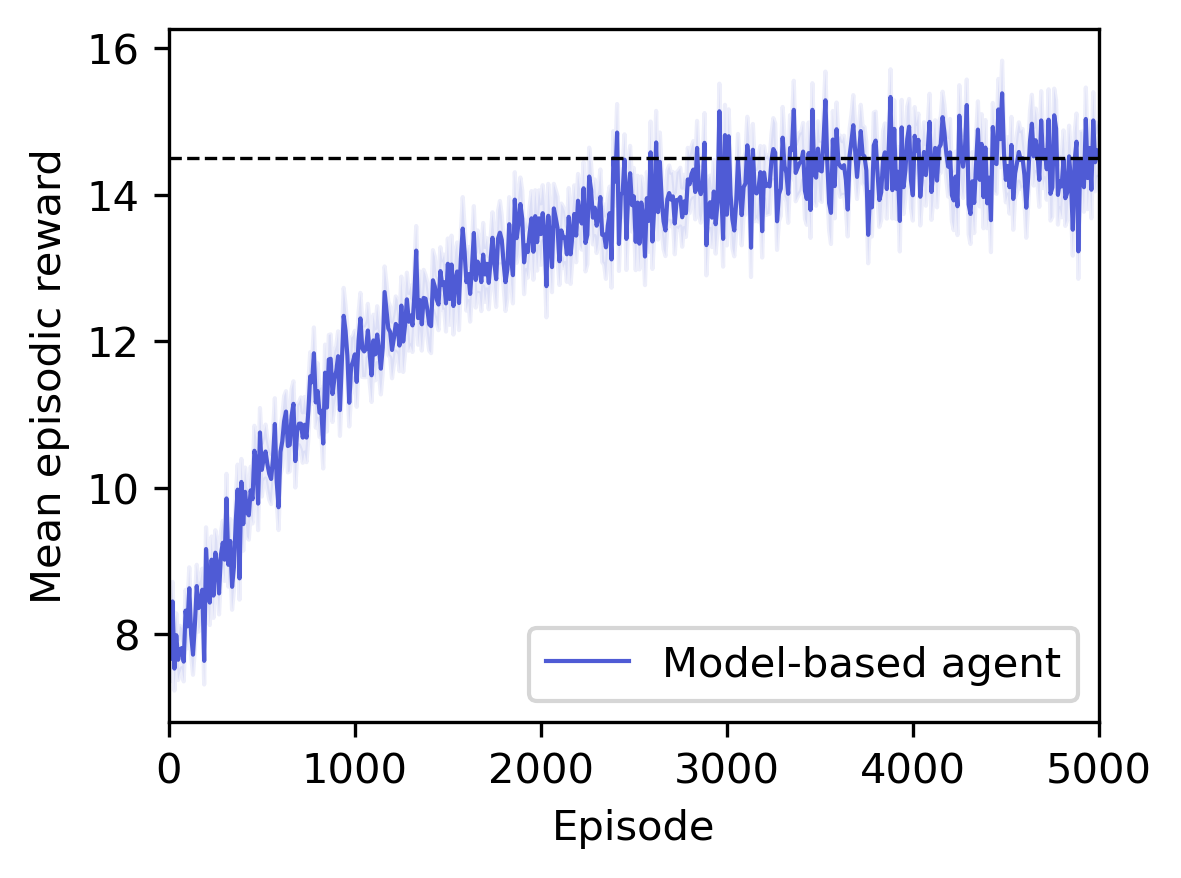

In [31]:
def sem(a, axis=0, ddof=1):
    # from scipy.stats.sem source
    n = a.shape[axis]
    s = np.std(a, axis=axis, ddof=1) / np.sqrt(n)
    return s


fig, ax = plt.subplots(1,1, figsize=(4,3), dpi=300)

# # for Q-learning agent
# x = np.arange(n_episodes//K)
# y = np.mean(q_agent_episode_rewards, axis=0)
# yerr = sem(q_agent_episode_rewards, axis=0)
# ax.plot(x, y, color='#d62976', lw=1, label='Model-free agent')
# ax.fill_between(x, y - yerr, y + yerr, color='#d62976', alpha=0.1)
# ax.axhline(14.5, c='k', lw=0.8, linestyle='--')

# for Hybrid agent
x = np.arange(n_episodes//K)
y = np.mean(hybrid_agent_episode_rewards, axis=0)
yerr = sem(hybrid_agent_episode_rewards, axis=0)
ax.plot(x, y, color='#4f5bd5', lw=1, label='Model-based agent')
ax.fill_between(x, y - yerr, y + yerr, color='#4f5bd5', alpha=0.1)
ax.axhline(14.5, c='k', lw=0.8, linestyle='--')
ax.set_xlim(0, 5000//K)
ax.legend(loc='lower right')
ax.set_xticks(np.arange(0,501,100))
ax.set_xticklabels([(i*10) for i in np.arange(0,501,100)])
ax.set_ylabel('Mean episodic reward')
ax.set_xlabel('Episode')


The Q-learning agent displayed a rapidly growing learning curve, yet it encountered an early plateau and did not reach the optimal state value(14.5). In contrast, the Hybrid agent demonstrated a slower learning curve but ultimately achieved the expected optimal return after the learning period. It should be noted that for clearer visualization, the average episodic reward over K(=10) consecutive episodes was used. The shaded band represents the standard error across independent runs.

#### Q2. Visualize how each of the two agents learned all the state-action value functions, Q(s,a) across trials and report the final learned values. Then, confirm that the two agents learned the optimal state-action values as shown in Supplementary Figure 1 (see the reference). 


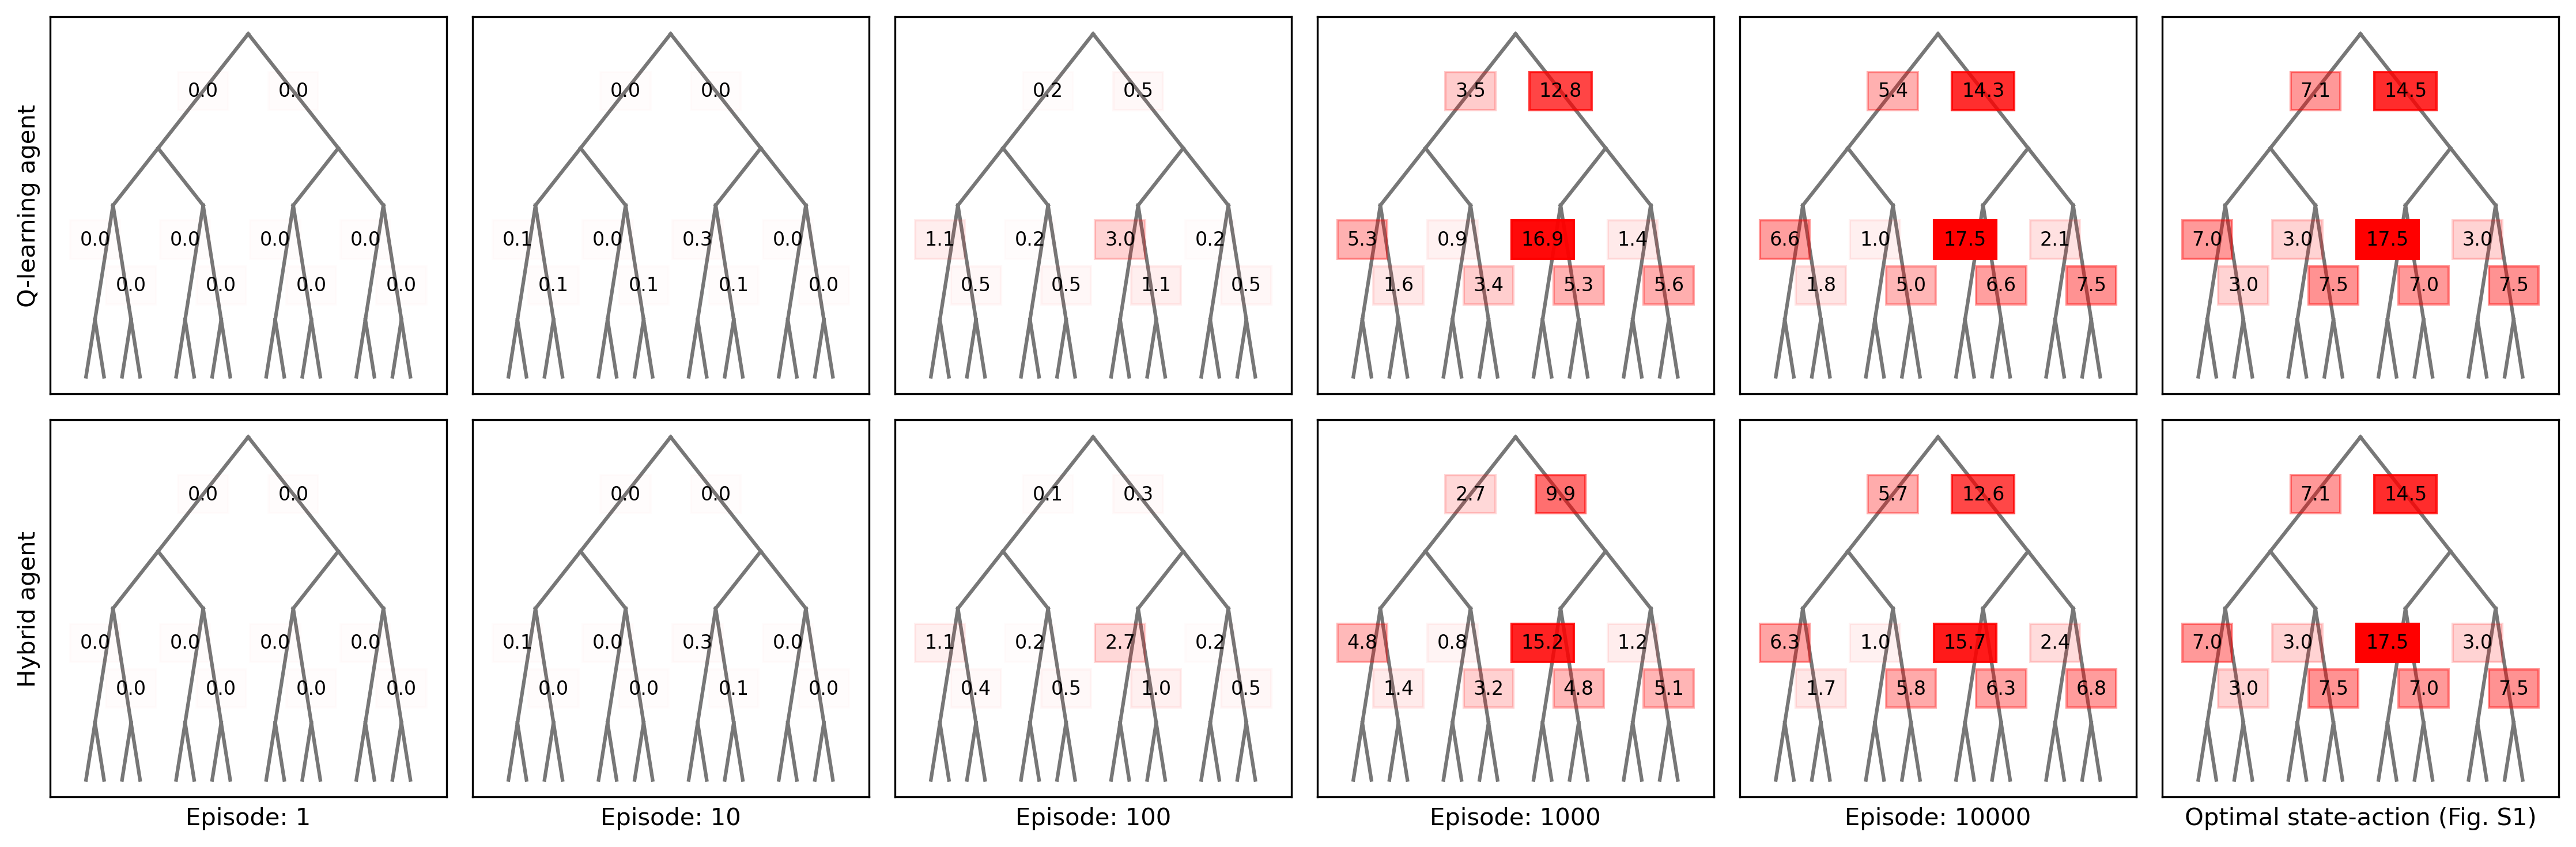

In [18]:
def draw_q_text(ax, x,y,value):
    ax.text(x, y, f'{value:0.1f}', 
            fontsize=8, va='center',ha='center', 
            bbox={'facecolor':'r', 'edgecolor':'r', 'alpha':np.clip(value/17.5, 0.01, 1.0)})
    
def visualize_state_action_value(ax, q_values):
    # Draw backbone
    branch_y = [12, 10, 9, 7, 6]
    # Branch 1
    ax.plot([0,-10], [branch_y[0], branch_y[1]], c='#777777')
    ax.plot([0,+10], [branch_y[0], branch_y[1]], c='#777777')
    # Branch 2
    ax.plot([10,10-5], [branch_y[1], branch_y[2]], c='#777777')
    ax.plot([10,10+5], [branch_y[1], branch_y[2]], c='#777777')
    ax.plot([-10,-10-5], [branch_y[1], branch_y[2]], c='#777777')
    ax.plot([-10,-10+5], [branch_y[1], branch_y[2]], c='#777777')
    # Branch 3
    ax.plot([10-5, 10-5-2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([10-5, 10-5+2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([10+5, 10+5-2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([10+5, 10+5+2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([-10-5, -10-5-2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([-10-5, -10-5+2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([-10+5, -10+5-2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([-10+5, -10+5+2], [branch_y[2], branch_y[3]], c='#777777')
    # Branch 4
    ax.plot([10-5-2, 10-5-2-1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([10-5-2, 10-5-2+1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([10-5+2, 10-5+2-1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([10-5+2, 10-5+2+1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([10+5-2, 10+5-2-1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([10+5-2, 10+5-2+1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([10+5+2, 10+5+2-1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([10+5+2, 10+5+2+1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([-10-5-2, -10-5-2-1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([-10-5-2, -10-5-2+1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([-10-5+2, -10-5+2-1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([-10-5+2, -10-5+2+1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([-10+5-2, -10+5-2-1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([-10+5-2, -10+5-2+1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([-10+5+2, -10+5+2-1], [branch_y[3], branch_y[4]], c='#777777')
    ax.plot([-10+5+2, -10+5+2+1], [branch_y[3], branch_y[4]], c='#777777')
    
    # visualize q values
    draw_q_text(ax, -5, np.mean([branch_y[0], branch_y[1]]), q_values[0,0])
    draw_q_text(ax, +5, np.mean([branch_y[0], branch_y[1]]), q_values[0,1])
    
    draw_q_text(ax, -15-2, np.mean([branch_y[2], branch_y[3]])+0.4, q_values[1,0])
    draw_q_text(ax, -15+2, np.mean([branch_y[2], branch_y[3]])-0.4, q_values[1,1])
    draw_q_text(ax, -5-2, np.mean([branch_y[2], branch_y[3]])+0.4, q_values[2,0])
    draw_q_text(ax, -5+2, np.mean([branch_y[2], branch_y[3]])-0.4, q_values[2,1])
    draw_q_text(ax, +5-2, np.mean([branch_y[2], branch_y[3]])+0.4, q_values[3,0])
    draw_q_text(ax, +5+2, np.mean([branch_y[2], branch_y[3]])-0.4, q_values[3,1])
    draw_q_text(ax, +15-2, np.mean([branch_y[2], branch_y[3]])+0.4, q_values[4,0])
    draw_q_text(ax, +15+2, np.mean([branch_y[2], branch_y[3]])-0.4, q_values[4,1])
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-22, 22)
    
optimal_q_vales = np.array([[7.1, 14.5],
                           [7.0, 3.0],
                           [3.0, 7.5],
                           [17.5, 7.0],
                           [3.0, 7.5]])
fig, axes = plt.subplots(2,6,figsize=(15,5), dpi=300, sharex=True, sharey=True)
axes[0,0].set_ylabel('Q-learning agent')
axes[1,0].set_ylabel('Hybrid agent')
axes[1,-1].set_xlabel('Optimal state-action (Fig. S1)')

for a, ax in enumerate(axes[0]):
    if a <= 4:
        visualize_state_action_value(ax, q_agent_q_values[a])
    else:
        visualize_state_action_value(ax, optimal_q_vales)
        
for a, ax in enumerate(axes[1]):
    if a <= 4:
        visualize_state_action_value(ax, hybrid_agent_q_values[a])
        ax.set_xlabel(f'Episode: {sampled_episodes[a]}')
    else:
        visualize_state_action_value(ax, optimal_q_vales)

plt.tight_layout()

Both agents demonstrated that the learned state-action Q values approached the optimal state-action Q values over trials, as illustrated in Supplementary Figure S1. By the end of the learning period (e.g., episode 10000), the Hybrid agent exhibited Q values that were closer to the ground truth than the model-free agent.

#### Q3. Explain how the optimal state-action values shown in Supplementary Figure 1 are calculated.


The optimal state-action values, as shown in Supplementary Figure S1, represent the expected returns of a current action in a given state. Two scenarios should be considered. First, when an agent receives the final reward at the end of a trial. For instance, if the agent performs action 0 (Go Left) at state 3, the agent will receive 25 points with a 70% probability and 0 points with a 30% probability. The expected return, e.g., Q(State 3, Left), would be `0.7 * 25 + 0.3 * 0 = 17.5`. This value is the Q value by definition. In the second scenario, where there is a subsequent state following a certain action, the optimal state-action values suppose the best possible outcomes for the next state. For example, if the agent chooses the action Go Right at State 0, Q(State 0, Right) will be the weighted sum of the best possible Q values for the next state, taking into account the next action. Thus, it will be `17.5 * 0.7 + 0.3 * 7.5 = 14.5`.

#### Q4. For the hybrid agent, visualize the hybrid agent learned transition probabilities as shown in Supplementary Figure 2 (see the reference) across trials.   
#### Then, confirm that the agent learned all the transition probabilities, as designed in the environment.  


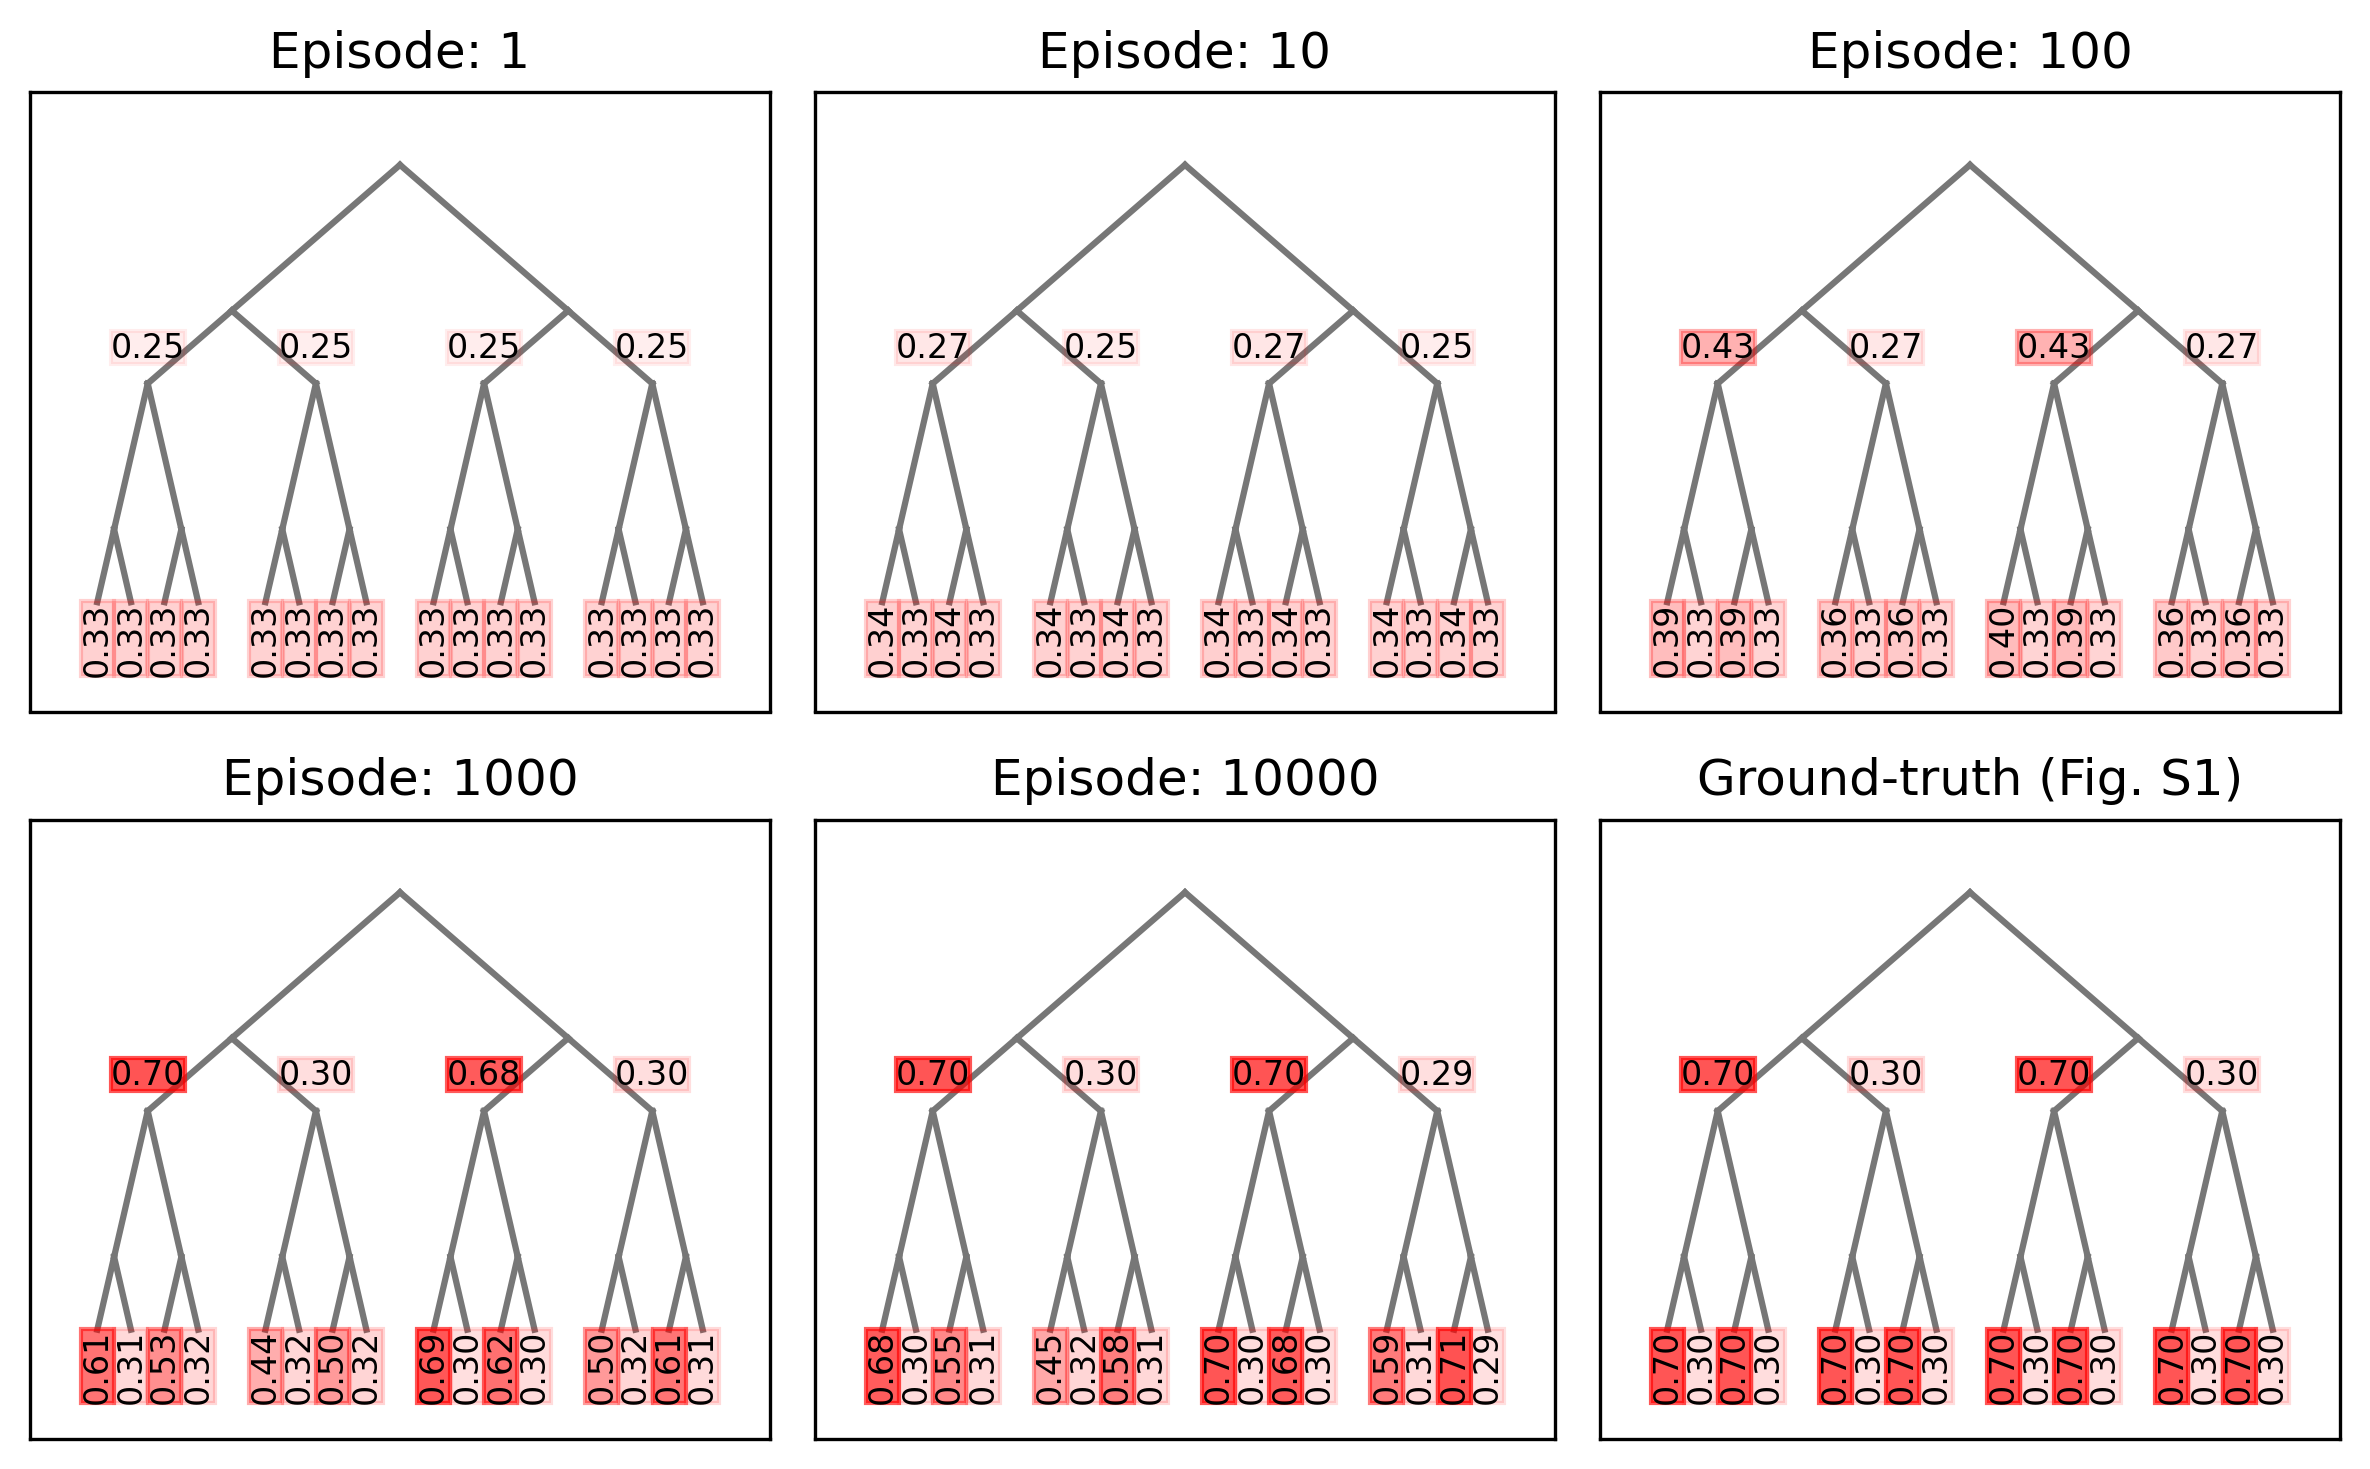

In [38]:
def draw_prob_text(ax, x,y, value, rot=0):
    ax.text(x, y, f'{value:0.2f}', 
            fontsize=8, va='center',ha='center', rotation=rot,
            bbox={'pad':0,'facecolor':'r', 
                  'edgecolor':'r', 'alpha':np.clip((value-0.2)/0.75, 0.01, 1.0)})
    
def visualize_transtion_prob(ax, trans):
    # Draw backbone
    branch_y = [12, 10, 9, 7, 6]
    # Branch 1
    ax.plot([0,-10], [branch_y[0], branch_y[1]], c='#777777')
    ax.plot([0,+10], [branch_y[0], branch_y[1]], c='#777777')
    # Branch 2
    ax.plot([10,10-5], [branch_y[1], branch_y[2]], c='#777777') #(0,0,1)
    draw_prob_text(ax, 10-5, np.mean([branch_y[1], branch_y[2]]), trans[(0,0,1)])
    ax.plot([10,10+5], [branch_y[1], branch_y[2]], c='#777777') #(0,0,2)
    draw_prob_text(ax, 10+5, np.mean([branch_y[1], branch_y[2]]), trans[(0,0,2)])
    ax.plot([-10,-10-5], [branch_y[1], branch_y[2]], c='#777777') #(0,1,3)
    draw_prob_text(ax, -10-5, np.mean([branch_y[1], branch_y[2]]), trans[(0,1,3)])
    ax.plot([-10,-10+5], [branch_y[1], branch_y[2]], c='#777777') #(0,1,4)
    draw_prob_text(ax, -10+5, np.mean([branch_y[1], branch_y[2]]), trans[(0,1,4)])
    # Branch 3
    ax.plot([10-5, 10-5-2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([10-5, 10-5+2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([10+5, 10+5-2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([10+5, 10+5+2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([-10-5, -10-5-2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([-10-5, -10-5+2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([-10+5, -10+5-2], [branch_y[2], branch_y[3]], c='#777777')
    ax.plot([-10+5, -10+5+2], [branch_y[2], branch_y[3]], c='#777777')
    # Branch 4
    ax.plot([10-5-2, 10-5-2-1], [branch_y[3], branch_y[4]], c='#777777') #(3,0,25)
    draw_prob_text(ax, 10-5-2-1, branch_y[4]-0.5, trans[(3,0,25)], rot=90)
    ax.plot([10-5-2, 10-5-2+1], [branch_y[3], branch_y[4]], c='#777777') #(3,0,0)
    draw_prob_text(ax, 10-5-2+1, branch_y[4]-0.5, trans[(3,0,0)], rot=90)
    ax.plot([10-5+2, 10-5+2-1], [branch_y[3], branch_y[4]], c='#777777') #(3,1,10)
    draw_prob_text(ax, 10-5+2-1, branch_y[4]-0.5, trans[(3,1,10)], rot=90)
    ax.plot([10-5+2, 10-5+2+1], [branch_y[3], branch_y[4]], c='#777777') #(3,1,0)
    draw_prob_text(ax, 10-5+2+1, branch_y[4]-0.5, trans[(3,1,0)], rot=90)
    
    ax.plot([10+5-2, 10+5-2-1], [branch_y[3], branch_y[4]], c='#777777') #(4,0,0)
    draw_prob_text(ax, 10+5-2-1, branch_y[4]-0.5, trans[(4,0,0)], rot=90)
    ax.plot([10+5-2, 10+5-2+1], [branch_y[3], branch_y[4]], c='#777777') #(4,0,10)
    draw_prob_text(ax, 10+5-2+1, branch_y[4]-0.5, trans[(4,0,10)], rot=90)
    ax.plot([10+5+2, 10+5+2-1], [branch_y[3], branch_y[4]], c='#777777') #(4,1,0)
    draw_prob_text(ax, 10+5+2-1, branch_y[4]-0.5, trans[(4,1,0)], rot=90)
    ax.plot([10+5+2, 10+5+2+1], [branch_y[3], branch_y[4]], c='#777777') #(4,1,25)
    draw_prob_text(ax, 10+5+2+1, branch_y[4]-0.5, trans[(4,1,25)], rot=90)
    
    ax.plot([-10-5-2, -10-5-2-1], [branch_y[3], branch_y[4]], c='#777777') #(1,0,10)
    draw_prob_text(ax, -10-5-2-1, branch_y[4]-0.5, trans[(1,0,10)], rot=90)
    ax.plot([-10-5-2, -10-5-2+1], [branch_y[3], branch_y[4]], c='#777777') #(1,0,0)
    draw_prob_text(ax, -10-5-2+1, branch_y[4]-0.5, trans[(1,0,0)], rot=90)
    ax.plot([-10-5+2, -10-5+2-1], [branch_y[3], branch_y[4]], c='#777777') #(1,1,0)
    draw_prob_text(ax, -10-5+2-1, branch_y[4]-0.5, trans[(1,1,0)], rot=90)
    ax.plot([-10-5+2, -10-5+2+1], [branch_y[3], branch_y[4]], c='#777777') #(1,1,10)
    draw_prob_text(ax, -10-5+2+1, branch_y[4]-0.5, trans[(1,1,10)], rot=90)
    
    ax.plot([-10+5-2, -10+5-2-1], [branch_y[3], branch_y[4]], c='#777777') #(2,0,0)
    draw_prob_text(ax, -10+5-2-1, branch_y[4]-0.5, trans[(2,0,0)], rot=90)
    ax.plot([-10+5-2, -10+5-2+1], [branch_y[3], branch_y[4]], c='#777777') #(2,0,10)
    draw_prob_text(ax, -10+5-2+1, branch_y[4]-0.5, trans[(2,0,10)], rot=90)
    ax.plot([-10+5+2, -10+5+2-1], [branch_y[3], branch_y[4]], c='#777777') #(2,1,0)
    draw_prob_text(ax, -10+5+2-1, branch_y[4]-0.5, trans[(2,1,0)], rot=90)
    ax.plot([-10+5+2, -10+5+2+1], [branch_y[3], branch_y[4]], c='#777777') #(2,1,25)
    draw_prob_text(ax, -10+5+2+1, branch_y[4]-0.5, trans[(2,1,25)], rot=90)
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-22, 22)
    ax.set_ylim(4.5, 13)

ground_truth_transitions = {(0,0,1):0.7, (0,0,2):0.3, (0,0,3):0.0, (0,0,4):0.0,  
                              (0,1,1):0.0, (0,1,2):0.0, (0,1,3):0.7, (0,1,4):0.3,
                              (1,0,0):0.3, (1,0,10):0.7, (1,0,25):0,
                              (2,0,0):0.7, (2,0,10):0.3, (2,0,25):0,
                              (3,0,0):0.3, (3,0,10):0, (3,0,25):0.7,
                              (4,0,0):0.7, (4,0,10):0.3, (4,0,25):0,
                              (1,1,0):0.7, (1,1,10):0.3, (1,1,25):0,
                              (2,1,0):0.7, (2,1,10):0.0, (2,1,25):0.3,
                              (3,1,0):0.3, (3,1,10):0.7, (3,1,25):0,
                              (4,1,0):0.7, (4,1,10):0, (4,1,25):0.3,
                             }
    
fig, axes = plt.subplots(2,3,figsize=(8,5), dpi=300, sharex=True, sharey=True)

a = 0
for i in range(2):
    for j in range(3):
        if a <= 4:
            visualize_transtion_prob(axes[i,j], hybrid_agent_transitions_mean[a])
            axes[i,j].set_title(f'Episode: {sampled_episodes[a]}')
        else: # plot grount-truth
            visualize_transtion_prob(axes[i,j], ground_truth_transitions)
            axes[i,j].set_title(f'Ground-truth (Fig. S1)')
        a += 1 

plt.tight_layout()

The Hybrid agent successfully learned the state transition probabilities of the given environment over several trials. However, it is noteworthy that even at the end of the learning period (e.g., episode 10000), the transition probabilities from rarely sampled states with low Q values, such as those from State 1, were less accurate compared to those from frequently sampled states with higher Q values. This inaccuracy may be attributed to a lack of learning experience in these rarely sampled states. It is also important to note that the sum of the probabilities of the inaccurately learned branches, as shown in the figure, does not equal 1. This is due to the presence of impossible state transitions that are not depicted in the figures.


## Reference
Gläscher, J., Daw, N., Dayan, P., & O'Doherty, J. P. (2010).   
States versus rewards: dissociable neural prediction error signals underlying model-based and model-free reinforcement learning. Neuron, 66(4), 585-595.






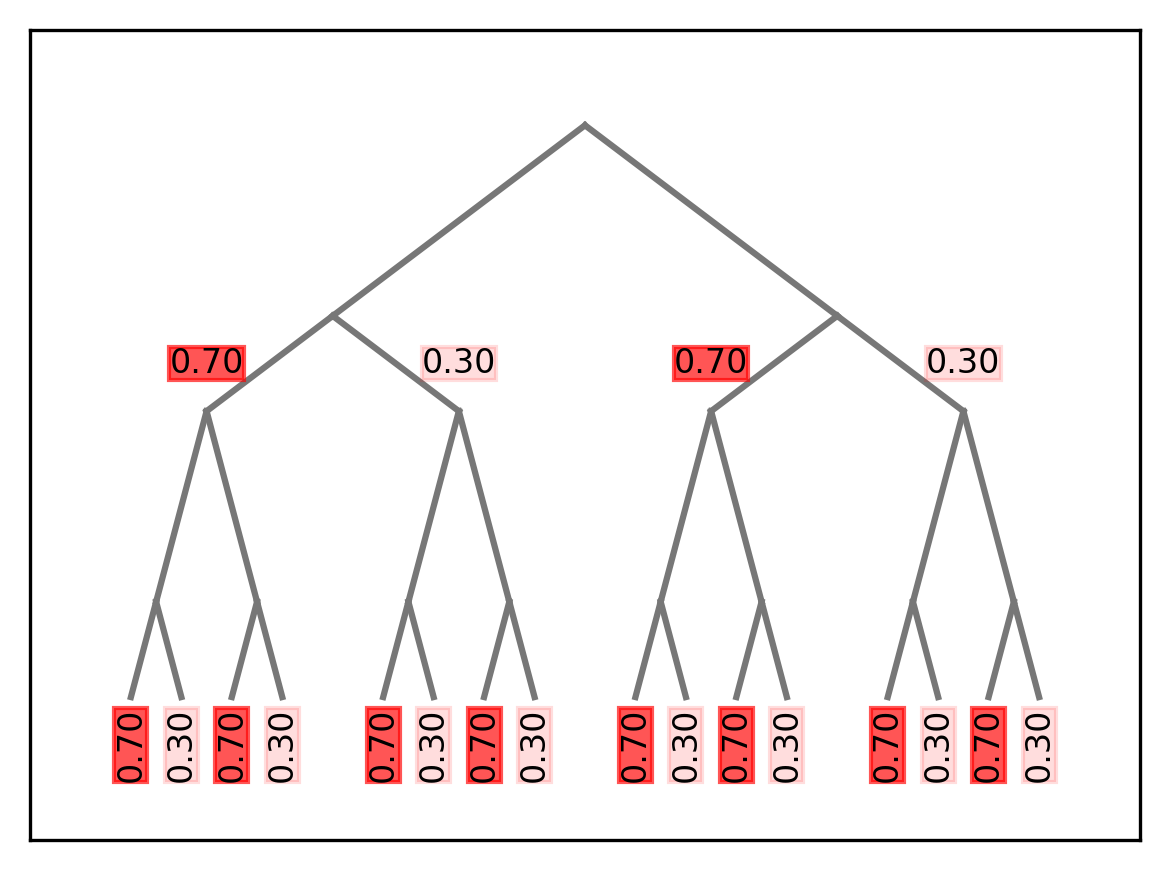

In [45]:
fig, axes = plt.subplots(1,1,figsize=(4,3), dpi=300, sharex=True, sharey=True)

a = 5
if a <= 4:
    visualize_transtion_prob(axes, hybrid_agent_transitions_mean[a])
    #axes.set_title(f'Episode: {sampled_episodes[a]}')
else: # plot grount-truth
    visualize_transtion_prob(axes, ground_truth_transitions)
    #axes.set_title(f'Ground-truth (Fig. S1)')

plt.tight_layout()